# Image-to-Text Model Pipeline Test

In this notebook we will be testing the full end to end Image-to-Text Model pipeline to ensure that it is ready to be used in our final application.

The pipeline will be executed in the following format:

1. Present an image of a note containing multiple lines of writing
2. Pass the image into preprocessing pipleine so that it can be input into first layer
3. **First Layer**: Passing image into a text detector (CRAFT or OpenCV) to isolate lines of text
4. Preprocess sentences to format useable for TROCR model
5. **Second Layer**: Run TROCR model and present results.

We will be using [Chinmays18/medical-perscription-dataset](https://huggingface.co/datasets/chinmays18/medical-prescription-dataset) as it gives us access to full synthetic perscriptions that we can use to test the models capabilities on full word document images.



## Imports and Installs

In [1]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from datasets import load_dataset
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    ViTImageProcessor,
    RobertaTokenizer
)

# Set device for Apple Silicon (MPS) or CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

/opt/anaconda3/envs/medicai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## Loading the Finetuned Image-to-text Model

In [2]:
MODEL_PATH = "../models/trocr_final_mdl"

# Fallback to base model if checkpoints haven't been exported yet
if not os.path.exists(MODEL_PATH):
    print(f"Custom model path '{MODEL_PATH}' not found. Loading base checkpoint for demonstration...")
    MODEL_PATH = "microsoft/trocr-base-handwritten"

image_processor = ViTImageProcessor.from_pretrained(MODEL_PATH)
tokenizer = RobertaTokenizer.from_pretrained(MODEL_PATH, use_fast=False)
processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

model = VisionEncoderDecoderModel.from_pretrained(MODEL_PATH).to(device)
model.eval()

print("TrOCR pipeline loaded successfully!")

Loading weights: 100%|██████████| 480/480 [00:00<00:00, 8521.83it/s]


TrOCR pipeline loaded successfully!


In [3]:
def segment_lines(image: Image.Image, min_height: int = 15, min_width: int = 30):
    """
    Isolates lines of handwritten text using adaptive thresholding and morphological dilation.
    """
    img_np = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # 1. Binarize using Otsu's thresholding
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 2. Horizontal morphological kernel to connect horizontal text components into line strips
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 3))
    dilated = cv2.dilate(thresh, kernel, iterations=2)

    # 3. Find bounding boxes of line segments
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Sort contours top-to-bottom
    bounding_boxes = [cv2.boundingRect(c) for c in contours]
    bounding_boxes = sorted(bounding_boxes, key=lambda b: b[1])

    line_crops = []
    annotated_img = img_np.copy()

    for x, y, w, h in bounding_boxes:
        if h >= min_height and w >= min_width:
            # Add small padding around cropped lines
            pad_y = max(0, y - 4)
            pad_h = min(img_np.shape[0] - pad_y, h + 8)
            pad_x = max(0, x - 4)
            pad_w = min(img_np.shape[1] - pad_x, w + 8)

            crop = img_np[pad_y:pad_y + pad_h, pad_x:pad_x + pad_w]
            line_crops.append(Image.fromarray(crop))

            # Draw visual bounding box for pipeline inspection
            cv2.rectangle(annotated_img, (pad_x, pad_y), (pad_x + pad_w, pad_y + pad_h), (0, 180, 0), 2)

    return line_crops, annotated_img

In [4]:
def recognize_text_lines(line_crops):
    """
    Processes each cropped line slice through the TrOCR encoder-decoder model.
    """
    recognized_lines = []

    for idx, crop in enumerate(line_crops):
        pixel_values = processor(crop, return_tensors="pt").pixel_values.to(device)

        with torch.no_grad():
            generated_ids = model.generate(pixel_values, max_new_tokens=64)

        pred_text = processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
        if pred_text.strip():
            recognized_lines.append(pred_text.strip())

    return recognized_lines

## Loading the Test Image

In [9]:
test_image_path = "../data/test_images"
test_image_file = "prescription_00002.png"
test_image = os.path.join(test_image_path, test_image_file)

# 1. Load local prescription image and matching JSON annotation (if available)
print(f"Loading local prescription document: {test_image}")
sample_full_image = Image.open(test_image).convert("RGB")

Loading local prescription document: ../data/test_images/prescription_00002.png


## Running the Model on the test Image

Detected 11 text line regions.


[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

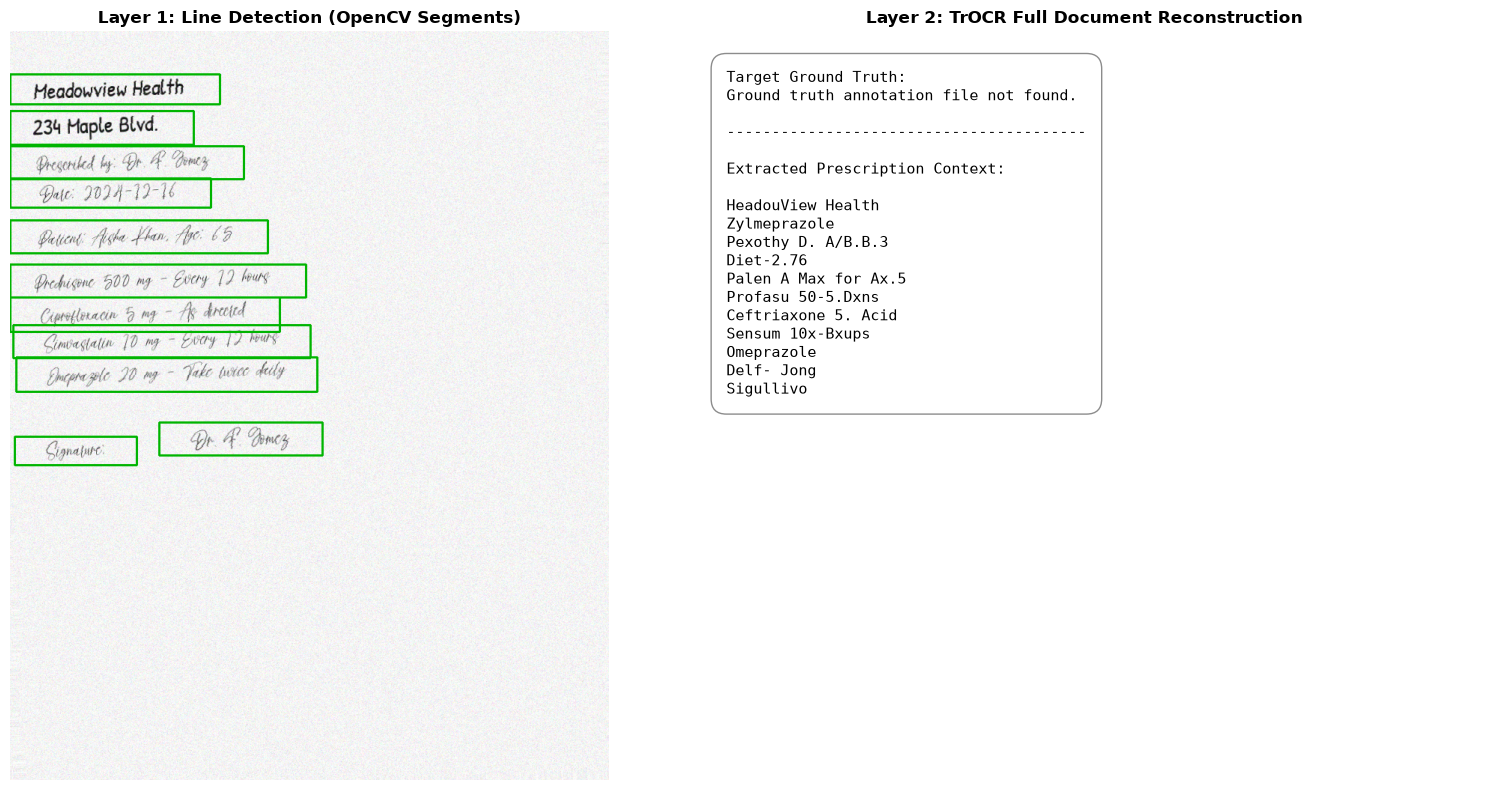


--- Final Recognized Text Output ---
HeadouView Health
Zylmeprazole
Pexothy D. A/B.B.3
Diet-2.76
Palen A Max for Ax.5
Profasu 50-5.Dxns
Ceftriaxone 5. Acid
Sensum 10x-Bxups
Omeprazole
Delf- Jong
Sigullivo


In [10]:
# Attempt to load corresponding ground truth JSON
base_name = os.path.splitext(test_image_file)[0]
test_annotation_file = os.path.join(test_image_path, f"{base_name}.json")

if os.path.exists(test_annotation_file):
    with open(test_annotation_file, "r") as f:
        annotation_data = json.load(f)
    ground_truth_text = annotation_data.get("ground_truth", "No annotation key found.")
else:
    ground_truth_text = "Ground truth annotation file not found."

# 2. Layer 1: Detect and slice lines
line_crops, annotated_canvas = segment_lines(sample_full_image)
print(f"Detected {len(line_crops)} text line regions.")

# 3. Layer 2: Perform TrOCR inference
extracted_lines = recognize_text_lines(line_crops)
full_extracted_prescription = "\n".join(extracted_lines)

# 4. Display Results
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(annotated_canvas)
axes[0].set_title("Layer 1: Line Detection (OpenCV Segments)", fontsize=12, fontweight="bold")
axes[0].axis("off")

# Format output comparison card
card_text = (
    f"Target Ground Truth:\n{ground_truth_text}\n\n"
    f"{'-'*40}\n\n"
    f"Extracted Prescription Context:\n\n{full_extracted_prescription}"
)

axes[1].text(
    0.05, 0.95,
    card_text,
    fontsize=11,
    verticalalignment="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=1", facecolor="white", edgecolor="gray", alpha=0.9)
)
axes[1].set_title("Layer 2: TrOCR Full Document Reconstruction", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("\n--- Final Recognized Text Output ---")
print(full_extracted_prescription)